<a href="https://colab.research.google.com/github/katelynnlindsey/phonology-chuvash/blob/main/logbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Acoustic analysis of Chuvash vowels

1. Obtain acoustic data

Chuvash-Voice

In [ ]:
from datasets import load_dataset, DatasetDict, concatenate_datasets, Audio

chuvash_voice = DatasetDict()
chuvash_voice = load_dataset("alexantonov/chuvash_voice")
chuvash_voice = chuvash_voice.cast_column("audio", Audio(sampling_rate=16000))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/446M [00:00<?, ?B/s]

KeyboardInterrupt: 

Common-Voice

Usage Instructions:
1. Replace YOUR_API_KEY with your actual API key in both commands
1.   Run the create download session command to get a download token
2. Replace DOWNLOAD_TOKEN with the token from step 1
3. Run the download command to get the dataset file

In [ ]:
curl -X POST "https://datacollective.mozillafoundation.org/api/datasets/cmj8u3oz40059nxxbu0wyqk1t/download" -H "Authorization: Bearer YOUR_API_KEY" -H "Content-Type: application/json"

In [ ]:
curl -X GET "https://datacollective.mozillafoundation.org/api/datasets/cmj8u3oz40059nxxbu0wyqk1t/download/DOWNLOAD_TOKEN" -H "Authorization: Bearer YOUR_API_KEY" -o "Common Voice Scripted Speech 24.0 - Chuvash.tar.gz"

Common Voice Chuvash textgrids from Vox Communis

Phonology class

2. Pre-process for Montreal Forced Aligner (MFA)

3. Run MFA

4. Pre-process for FAVE vowel extraction

chuvash-manual-recode.py

5. Run new-FAVE

In [ ]:
!pip install new-fave

In [ ]:
chuvash-fave.py

6. Combine extracted vowel data

chuvash-combine.py

7. Visualize results

Import dataframe and filter for vowels

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Define Path to the COMBINED CSV ---
base_corpus_path = "/content"
combined_csv_path = os.path.join(base_corpus_path, "all_chuvash_vowel_points.csv")

# --- Load the combined data ONCE ---
try:
    combined_df = pd.read_csv(combined_csv_path, encoding='utf-8')
    print(f"Successfully loaded combined data with {len(combined_df)} entries.")
    print("Columns available:", combined_df.columns.tolist())

    # Filter for only vowel labels (exclude SIL and any non-vowel markers)
    # Adjust this list if you have other non-vowel labels you want to exclude
    vowels_df = combined_df[~combined_df['label'].isin(['SIL', '<eps>', '#'])].copy()
    print(f"Filtered for vowels: {len(vowels_df)} entries remaining.")

except FileNotFoundError:
    print(f"Error: Combined CSV file not found at '{combined_csv_path}'. Please run 'combine_fave_points_data.py' first.")
    # Exit or handle the error appropriately if running as a script
    # For a notebook, you might just display an error and let the user fix it.
except Exception as e:
    print(f"An error occurred while loading or preparing data: {e}")
    # Handle error
    vowels_df = pd.DataFrame() # Create an empty DataFrame to prevent further errors if loading fails

Successfully loaded combined data with 153153 entries.
Columns available: ['F1', 'F2', 'F3', 'B1', 'B2', 'B3', 'max_formant', 'smooth_error', 'time', 'rel_time', 'prop_time', 'id', 'label', 'file_name', 'group', 'speaker_num', 'point_heuristic', 'f0', 'intensity', 'optimized', 'word', 'stress', 'dur', 'pre_word', 'fol_word', 'pre_seg', 'fol_seg', 'abs_pre_seg', 'abs_fol_seg', 'context', 'sidx', 'sN', 'syl_pos', 'syl_open_closed', 'corpus']
Filtered for vowels: 121364 entries remaining.


Filter dataframe by removing outliers

In [2]:
import pandas as pd
import numpy as np

# Assuming your DataFrame is loaded as 'df'
# Example: df = pd.read_csv('your_data.csv') # or whatever method you use to load your data

# Columns to check for outliers
outlier_columns = ['F1', 'F2', 'dur', 'intensity', 'f0']

# Function to detect and filter outliers using the IQR method
def filter_outliers_iqr(df_group, column):
    Q1 = df_group[column].quantile(0.25)
    Q3 = df_group[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df_group[(df_group[column] >= lower_bound) & (df_group[column] <= upper_bound)]

# Apply the outlier filtering for each vowel category ('label') and for each specified column
filtered_df = vowels_df.copy() # Start with a copy of your original DataFrame

for col in outlier_columns:
    print(f"Filtering outliers for column: {col}")
    # Group by 'label' and apply the filtering function
    filtered_df = filtered_df.groupby('label').apply(lambda x: filter_outliers_iqr(x, col)).reset_index(drop=True)
    # The .reset_index(drop=True) is important because .apply with groupby can add extra index levels.

print(f"\nOriginal DataFrame shape: {vowels_df.shape}")
print(f"Filtered DataFrame shape: {filtered_df.shape}")

# You can also see how many rows were removed
rows_removed = vowels_df.shape[0] - filtered_df.shape[0]
print(f"{rows_removed} rows were identified as outliers and removed.")

# Display the first few rows of your cleaned data
print("\nFiltered DataFrame head:")
print(filtered_df.head())

Filtering outliers for column: F1


/tmp/ipython-input-2261667577.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = filtered_df.groupby('label').apply(lambda x: filter_outliers_iqr(x, col)).reset_index(drop=True)


Filtering outliers for column: F2


/tmp/ipython-input-2261667577.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = filtered_df.groupby('label').apply(lambda x: filter_outliers_iqr(x, col)).reset_index(drop=True)


Filtering outliers for column: dur


/tmp/ipython-input-2261667577.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = filtered_df.groupby('label').apply(lambda x: filter_outliers_iqr(x, col)).reset_index(drop=True)


Filtering outliers for column: intensity


/tmp/ipython-input-2261667577.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = filtered_df.groupby('label').apply(lambda x: filter_outliers_iqr(x, col)).reset_index(drop=True)


Filtering outliers for column: f0

Original DataFrame shape: (121364, 35)
Filtered DataFrame shape: (98567, 35)
22797 rows were identified as outliers and removed.

Filtered DataFrame head:
           F1           F2           F3        B1        B2        B3  \
0  528.992446  1457.081819  2468.502558  3.221750  3.463196  4.857913   
1  664.508959  1377.380633  2643.935273  3.031897  3.759868  3.675911   
2  570.083014  1363.482708  2369.615018  3.286202  3.807272  3.704648   
3  534.513019  1741.639930  2694.016958  2.811123  3.169634  3.084331   
4  794.435529  1625.765509  2638.632535  3.734071  3.949547  4.043299   

   max_formant  smooth_error      time  rel_time  ...  pre_seg fol_seg  \
0  4615.384615      0.000087  2.297375     0.027  ...        J       N   
1  4615.384615      0.000004  1.056375     0.025  ...        #       D   
2  4974.358974      0.000007  1.176375     0.025  ...        L       M   
3  4974.358974      0.000004  1.417375     0.027  ...        T       R   
4

/tmp/ipython-input-2261667577.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = filtered_df.groupby('label').apply(lambda x: filter_outliers_iqr(x, col)).reset_index(drop=True)


Plot F1 x F2

/tmp/ipython-input-564892372.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(base_labels)) # 'tab10' is a good categorical colormap


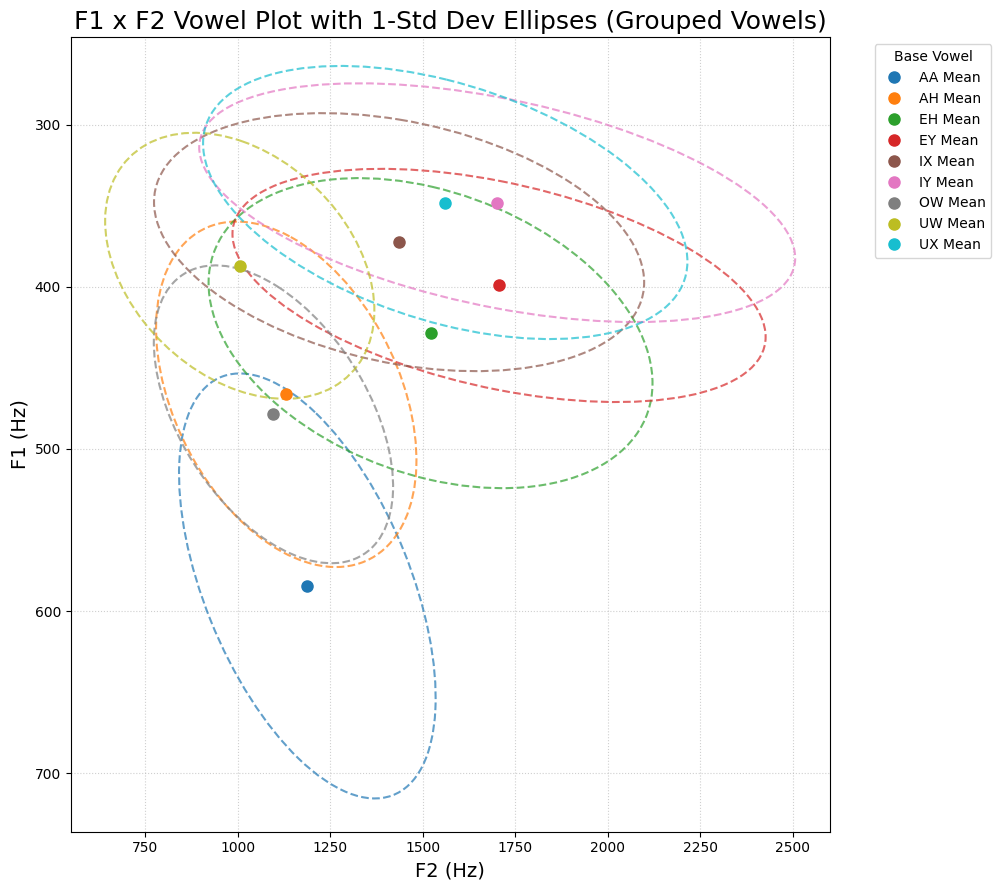

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.cm as cm # For color mapping
import re # Regular expression library for stripping numbers

# --- Start of placeholder for filtered_df if running standalone ---
# In your Google Colab notebook, 'filtered_df' should already exist from the previous steps.
# This block is just for demonstration if you run this code snippet independently.
if 'filtered_df' not in locals():
    print("Warning: 'filtered_df' not found. Creating dummy data for demonstration.")
    np.random.seed(42) # for reproducibility
    data = {
        'F1': np.random.normal(500, 50, 50).tolist() + np.random.normal(520, 45, 50).tolist() + # AA1, AA0
              np.random.normal(700, 60, 50).tolist() + np.random.normal(710, 55, 50).tolist() + # IY1, IY0
              np.random.normal(300, 40, 50).tolist() + np.random.normal(310, 35, 50).tolist() + # UW1, UW0
              np.random.normal(450, 45, 50).tolist() + np.random.normal(460, 40, 50).tolist(),  # AE1, AE0
        'F2': np.random.normal(1500, 100, 50).tolist() + np.random.normal(1550, 90, 50).tolist() +
              np.random.normal(1200, 80, 50).tolist() + np.random.normal(1250, 75, 50).tolist() +
              np.random.normal(2000, 120, 50).tolist() + np.random.normal(2050, 110, 50).tolist() +
              np.random.normal(1800, 90, 50).tolist() + np.random.normal(1850, 85, 50).tolist(),
        'label': ['AA1']*50 + ['AA0']*50 + ['IY1']*50 + ['IY0']*50 +
                 ['UW1']*50 + ['UW0']*50 + ['AE1']*50 + ['AE0']*50,
        'dur': np.random.rand(400), 'intensity': np.random.rand(400), 'f0': np.random.rand(400)
    }
    filtered_df = pd.DataFrame(data)
    filtered_df['F1'] = pd.to_numeric(filtered_df['F1'])
    filtered_df['F2'] = pd.to_numeric(filtered_df['F2'])
# --- End of placeholder ---


# --- New step: Create 'base_vowel' column ---
# This uses a regular expression to remove any trailing digits from the 'label'
filtered_df['base_vowel'] = filtered_df['label'].apply(lambda x: re.sub(r'[0-9]', '', x))

# Group by 'base_vowel' to calculate mean and covariance for F1 and F2
vowel_means = filtered_df.groupby('base_vowel')[['F1', 'F2']].mean()

# Dictionary to store covariance matrices for each base vowel
vowel_covariances = {}
for base_vowel_label in filtered_df['base_vowel'].unique():
    subset = filtered_df[filtered_df['base_vowel'] == base_vowel_label][['F1', 'F2']]
    # Ensure there's enough data for covariance calculation (at least 2 points)
    if len(subset) > 1:
        vowel_covariances[base_vowel_label] = np.cov(subset['F1'], subset['F2'])
    else:
        print(f"Warning: Not enough data for '{base_vowel_label}' to calculate covariance matrix. Skipping ellipse.")
        vowel_covariances[base_vowel_label] = None # Store None to skip plotting ellipse

# Set up the plot
fig, ax = plt.subplots(figsize=(12, 9))

# Get a color map for distinct colors for each base vowel
base_labels = filtered_df['base_vowel'].unique()
colors = cm.get_cmap('tab10', len(base_labels)) # 'tab10' is a good categorical colormap

# Plot each base vowel's mean and 1-standard deviation ellipse
for i, base_vowel_label in enumerate(base_labels):
    mean_f1 = vowel_means.loc[base_vowel_label, 'F1']
    mean_f2 = vowel_means.loc[base_vowel_label, 'F2']
    color = colors(i)

    # Plot the mean point
    ax.plot(mean_f2, mean_f1, 'o', color=color, markersize=8, label=f'{base_vowel_label} Mean', zorder=5)

    # Plot ellipse only if covariance matrix was successfully calculated
    cov_matrix = vowel_covariances.get(base_vowel_label)
    if cov_matrix is not None:
        # Calculate ellipse parameters from the covariance matrix
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Sort eigenvalues in descending order and get corresponding eigenvectors
        order = eigenvalues.argsort()[::-1]
        eigenvalues = eigenvalues[order]
        eigenvectors = eigenvectors[:, order]

        # The angle of the ellipse is the angle of the eigenvector corresponding to the largest eigenvalue
        angle = np.degrees(np.arctan2(*eigenvectors[:, 0]))

        # For a "1 standard deviation" ellipse, the half-axes are proportional to sqrt(eigenvalues).
        width, height = 2 * np.sqrt(eigenvalues)

        # Create and add the ellipse patch
        ellipse = Ellipse((mean_f2, mean_f1), width=width, height=height,
                          angle=angle, facecolor='none', edgecolor=color,
                          linestyle='--', linewidth=1.5, alpha=0.7, zorder=3)
        ax.add_patch(ellipse)
    else:
        print(f"Skipping ellipse for '{base_vowel_label}' due to insufficient data for covariance calculation.")


# Customize the plot
ax.set_title('F1 x F2 Vowel Plot with 1-Std Dev Ellipses (Grouped Vowels)', fontsize=18)
ax.set_xlabel('F2 (Hz)', fontsize=14)
ax.set_ylabel('F1 (Hz)', fontsize=14)
ax.invert_yaxis() # F1 is traditionally inverted in phonetic plots
ax.invert_xaxis() # F2 is traditionally inverted in phonetic plots
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(title='Base Vowel', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10) # Place legend outside
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for the legend
plt.show()

Bar plot of vowel durations

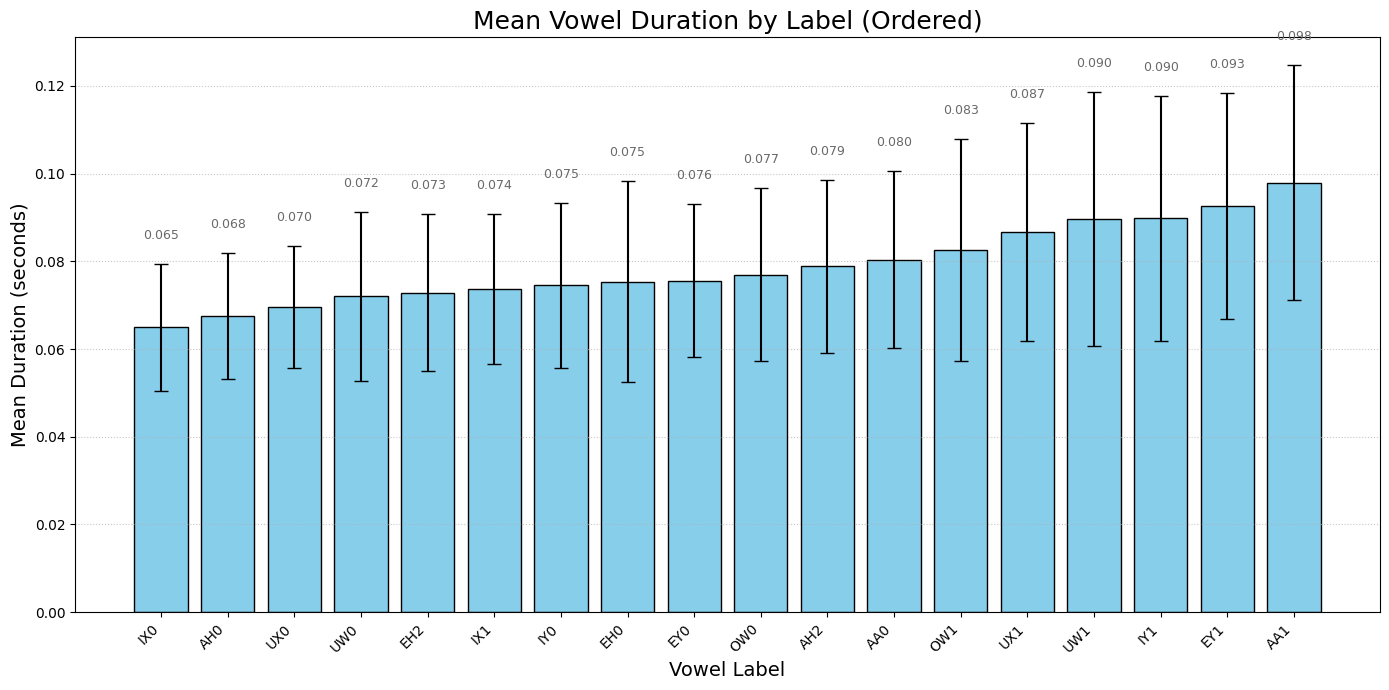

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# --- Start of placeholder for filtered_df if running standalone ---
if 'filtered_df' not in locals():
    print("Warning: 'filtered_df' not found. Creating dummy data for demonstration.")
    np.random.seed(42) # for reproducibility
    data = {
        'F1': np.random.normal(500, 50, 50).tolist() + np.random.normal(520, 45, 50).tolist() +
              np.random.normal(700, 60, 50).tolist() + np.random.normal(710, 55, 50).tolist() +
              np.random.normal(300, 40, 50).tolist() + np.random.normal(310, 35, 50).tolist() +
              np.random.normal(450, 45, 50).tolist() + np.random.normal(460, 40, 50).tolist(),
        'F2': np.random.normal(1500, 100, 50).tolist() + np.random.normal(1550, 90, 50).tolist() +
              np.random.normal(1200, 80, 50).tolist() + np.random.normal(1250, 75, 50).tolist() +
              np.random.normal(2000, 120, 50).tolist() + np.random.normal(2050, 110, 50).tolist() +
              np.random.normal(1800, 90, 50).tolist() + np.random.normal(1850, 85, 50).tolist(),
        'label': ['AA1']*50 + ['AA0']*50 + ['IY1']*50 + ['IY0']*50 +
                 ['UW1']*50 + ['UW0']*50 + ['AE1']*50 + ['AE0']*50,
        'dur': np.random.uniform(0.05, 0.3, 400), # Realistic durations
        'intensity': np.random.rand(400), 'f0': np.random.rand(400)
    }
    filtered_df = pd.DataFrame(data)
    filtered_df['F1'] = pd.to_numeric(filtered_df['F1'])
    filtered_df['F2'] = pd.to_numeric(filtered_df['F2'])
    filtered_df['dur'] = pd.to_numeric(filtered_df['dur'])
# --- End of placeholder ---

# Calculate mean and standard deviation of duration for each 'label'
duration_stats = filtered_df.groupby('label')['dur'].agg(['mean', 'std']).sort_values('mean').reset_index()

# Set up the plot
fig, ax = plt.subplots(figsize=(14, 7)) # Adjust figure size for better readability

# Create the bar plot
bars = ax.bar(duration_stats['label'], duration_stats['mean'],
              yerr=duration_stats['std'], capsize=5, color='skyblue', edgecolor='black')

# Customize the plot
ax.set_title('Mean Vowel Duration by Label (Ordered)', fontsize=18)
ax.set_xlabel('Vowel Label', fontsize=14)
ax.set_ylabel('Mean Duration (seconds)', fontsize=14)

ax.tick_params(axis='x', labelrotation=45, labelsize=10) # Rotate x-axis labels
plt.setp(ax.get_xticklabels(), ha='right')

ax.grid(axis='y', linestyle=':', alpha=0.7) # Add horizontal grid lines

# Optional: Add duration values on top of the bars for precise reading
# Iterate through bars AND the duration_stats DataFrame to get std values
for i, bar in enumerate(bars):
    yval = bar.get_height()
    # Get the standard deviation directly from the duration_stats DataFrame for the current bar's index
    yerr_val = duration_stats['std'].iloc[i] if pd.notna(duration_stats['std'].iloc[i]) else 0

    # Position text above bar + error, making sure it doesn't overlap the error bar cap
    ax.text(bar.get_x() + bar.get_width()/2, yval + yerr_val + 0.005,
            f"{yval:.3f}", ha='center', va='bottom', fontsize=9, color='dimgray') # Corrected color

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

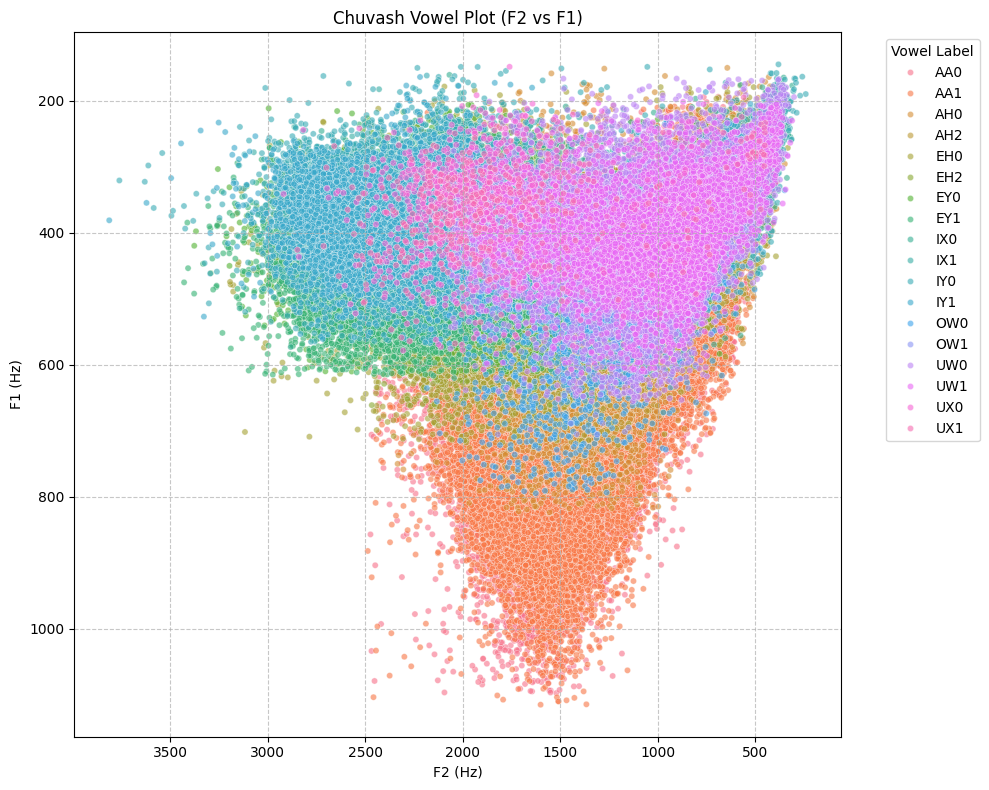

In [17]:
# Cell 1: Basic Vowel Plot (F2 vs F1)
if not filtered_df.empty:
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=filtered_df, x='F2', y='F1', hue='label', alpha=0.6, s=20)
    plt.gca().invert_xaxis() # Invert F2 axis as is common in phonetics
    plt.gca().invert_yaxis() # Invert F1 axis as is common in phonetics
    plt.title('Chuvash Vowel Plot (F2 vs F1)')
    plt.xlabel('F2 (Hz)')
    plt.ylabel('F1 (Hz)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Vowel Label', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No vowel data available for F1/F2 plot.")

/tmp/ipython-input-1296570587.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=filtered_df, x='label', y='F1', inner='quartile', palette='viridis')


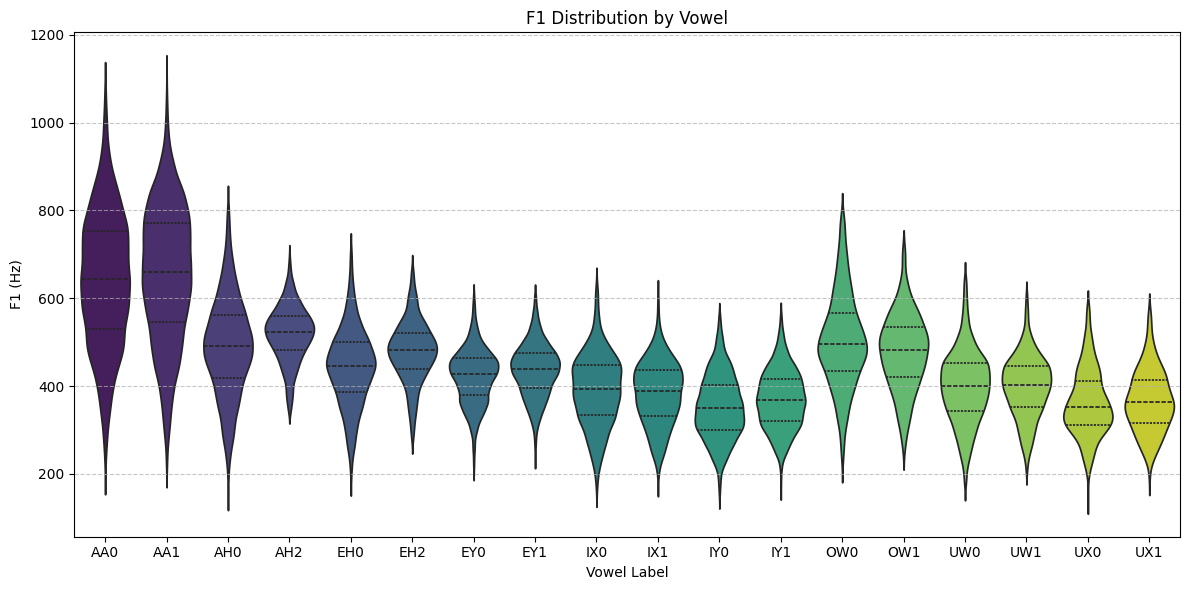

In [18]:
# Cell 2: F1 Distribution by Vowel
if not filtered_df.empty:
    plt.figure(figsize=(12, 6))
    sns.violinplot(data=filtered_df, x='label', y='F1', inner='quartile', palette='viridis')
    plt.title('F1 Distribution by Vowel')
    plt.xlabel('Vowel Label')
    plt.ylabel('F1 (Hz)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No vowel data available for F1 distribution plot.")

/tmp/ipython-input-2083804386.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_df, x='label', y='dur', palette='plasma')


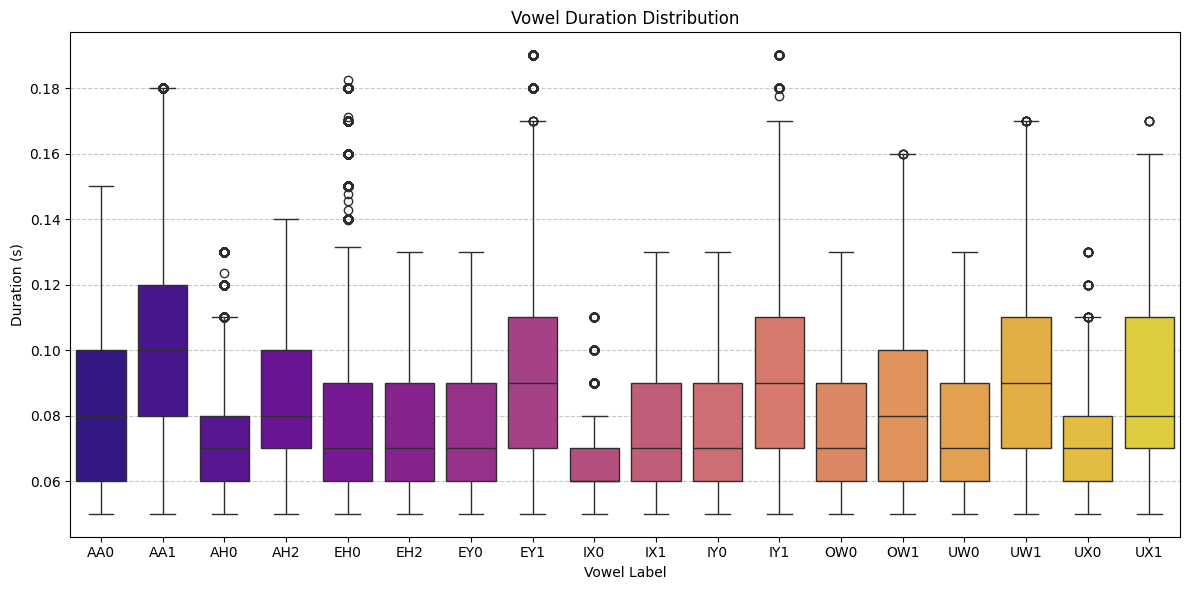

In [19]:
# Cell 3: Duration Distribution by Vowel
if not filtered_df.empty:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=filtered_df, x='label', y='dur', palette='plasma')
    plt.title('Vowel Duration Distribution')
    plt.xlabel('Vowel Label')
    plt.ylabel('Duration (s)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No vowel data available for duration plot.")

/tmp/ipython-input-3854675809.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=vowels_df_filtered, x='label', y='dur', palette='viridis', order=ordered_vowels)


ANOVA F-statistic: 1398.52, p-value: 0.000

ANOVA results indicate significant differences between vowel groups (p < 0.05).
Performing Tukey HSD post-hoc test for pairwise comparisons:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   AA0    AA1   0.0137    0.0  0.0131  0.0144   True
   AA0    AH0  -0.0111    0.0  -0.012 -0.0103   True
   AA0    AH2   0.0003    1.0 -0.0015  0.0021  False
   AA0    EH0  -0.0057    0.0 -0.0065 -0.0048   True
   AA0    EH2   -0.005    0.0  -0.007  -0.003   True
   AA0    EY0  -0.0053    0.0 -0.0063 -0.0043   True
   AA0    EY1     0.01    0.0  0.0093  0.0107   True
   AA0    IX0  -0.0158    0.0 -0.0177 -0.0139   True
   AA0    IX1  -0.0072    0.0 -0.0094 -0.0051   True
   AA0    IY0  -0.0061    0.0 -0.0071 -0.0051   True
   AA0    IY1   0.0066    0.0  0.0055  0.0077   True
   AA0    OW0  -0.0045    0.0 -0.0062 -0.0028   True
   AA0    OW1    0.0

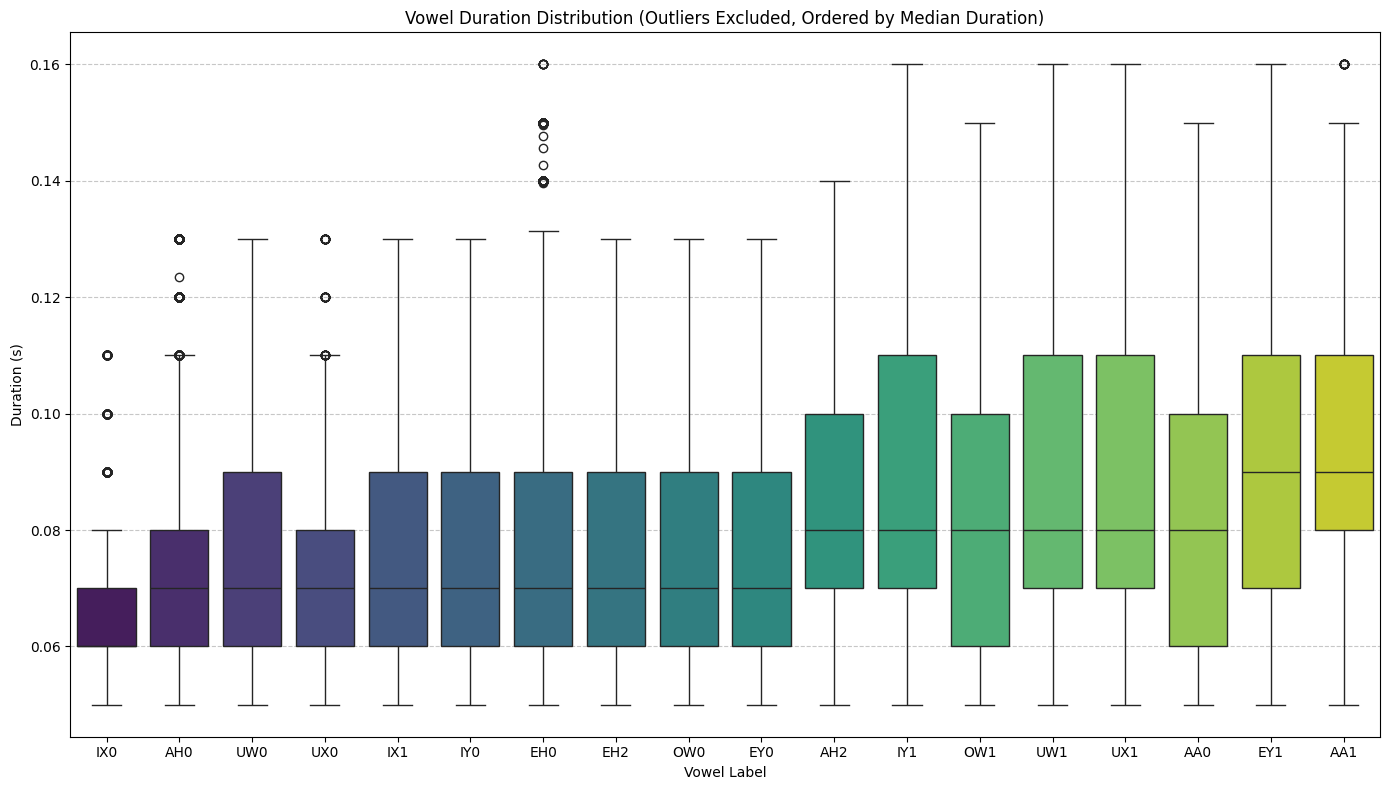

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # For f_oneway (ANOVA)
from statsmodels.stats.multicomp import pairwise_tukeyhsd # For Tukey HSD
import pandas as pd # Ensure pandas is imported if not already

# --- START: Dummy vowels_df creation for demonstration ---
# This block is for demonstration purposes. In your actual Jupyter Notebook,
# 'vowels_df' should already be populated from your data processing.
try:
    # Attempt to access vowels_df to see if it exists
    _ = vowels_df.head()
except NameError:
    print("Dummy 'vowels_df' created for demonstration. In actual use, ensure your 'vowels_df' is loaded.")
    data = {
        'label': np.random.choice(['a', 'e', 'i', 'o', 'u', 'ɪ', 'ɛ'], size=1000),
        'dur': np.random.normal(loc=0.15, scale=0.05, size=1000) # Base durations
    }
    # Add some outliers and variations for testing
    data['dur'][::10] = np.random.uniform(0.5, 1.0, size=100) # Longer outliers
    data['dur'][data['label'] == 'a'] += 0.03 # Make 'a' slightly longer on average
    data['dur'][data['label'] == 'i'] -= 0.02 # Make 'i' slightly shorter on average
    vowels_df = pd.DataFrame(data)
# --- END: Dummy vowels_df creation ---


if not filtered_df.empty:
    # 1. Outlier Filtering using IQR (from previous response)
    Q1 = filtered_df['dur'].quantile(0.25)
    Q3 = filtered_df['dur'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out data points outside the outlier bounds
    vowels_df_filtered = filtered_df[(filtered_df['dur'] >= lower_bound) & (filtered_df['dur'] <= upper_bound)]

    # 2. Arrange vowels from shortest to longest median duration
    # Calculate median duration for each vowel label in the filtered data
    median_durations = vowels_df_filtered.groupby('label')['dur'].median().sort_values()
    ordered_vowels = median_durations.index.tolist()

    plt.figure(figsize=(14, 8)) # Increased figure size for better readability
    ax = sns.boxplot(data=vowels_df_filtered, x='label', y='dur', palette='viridis', order=ordered_vowels)
    plt.title('Vowel Duration Distribution (Outliers Excluded, Ordered by Median Duration)')
    plt.xlabel('Vowel Label')
    plt.ylabel('Duration (s)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # 3. Perform statistical tests for significance bars
    # Ensure there are at least two unique vowel labels after filtering to perform comparisons
    if len(ordered_vowels) > 1:
        # Prepare groups for ANOVA: a list of duration arrays for each vowel
        groups_for_anova = [vowels_df_filtered['dur'][vowels_df_filtered['label'] == v] for v in ordered_vowels]
        # Filter out any empty groups that might result from filtering
        groups_for_anova = [g for g in groups_for_anova if not g.empty]

        if len(groups_for_anova) > 1:
            # Perform One-way ANOVA to test for overall significant differences
            f_stat, p_anova = stats.f_oneway(*groups_for_anova)
            print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_anova:.3f}")

            # If ANOVA is significant, proceed with post-hoc Tukey HSD test for pairwise comparisons
            if p_anova < 0.05: # Common significance level
                print("\nANOVA results indicate significant differences between vowel groups (p < 0.05).")
                print("Performing Tukey HSD post-hoc test for pairwise comparisons:")

                # Perform Tukey HSD
                tukey_result = pairwise_tukeyhsd(endog=vowels_df_filtered['dur'],
                                                  groups=vowels_df_filtered['label'],
                                                  alpha=0.05) # Significance level
                print(tukey_result) # Prints a table of pairwise comparisons

                # 4. Add significance bars using the 'statannotations' library
                try:
                    from statannotations.Annotator import Annotator
                    print("\n'statannotations' library found. Drawing significance bars for significant pairwise differences...")

                    comparison_pairs = []
                    p_values_for_annotator = []

                    # Iterate through Tukey HSD results to identify significant pairs
                    rows = tukey_result.summary().data[1:] # Skip header row of the summary table
                    for row_data in rows:
                        group1, group2, _, _, p_value, reject_null = row_data
                        # If the null hypothesis is rejected, this pair is significantly different
                        if reject_null: # 'reject_null' is True if p_value < alpha (0.05 in this case)
                            # Ensure the pair is ordered correctly for statannotations based on 'ordered_vowels'
                            idx1 = ordered_vowels.index(group1)
                            idx2 = ordered_vowels.index(group2)

                            if idx1 < idx2:
                                pair = (group1, group2)
                            else:
                                pair = (group2, group1)

                            comparison_pairs.append(pair)
                            p_values_for_annotator.append(p_value)

                    if comparison_pairs:
                        # Initialize Annotator with the axis, comparison pairs, data, and column names
                        annotator = Annotator(ax, comparison_pairs, data=vowels_df_filtered,
                                              x='label', y='dur', order=ordered_vowels)
                        # Configure to use star notation (*, **, ***) for significance and place bars outside the plot area
                        annotator.configure(test=None, text_format='star', loc='outside')
                        # Pass the pre-calculated p-values to the annotator for drawing
                        annotator.set_pvalues_and_annotate(p_values=p_values_for_annotator)
                    else:
                        print("No significant pairwise differences (p < 0.05) found to annotate on the plot.")

                except ImportError:
                    print("\n'statannotations' library not found. To draw significance bars on the plot, please install it:")
                    print("pip install statannotations")
                    print("Proceeding without drawing significance bars on the plot, but Tukey HSD results are printed above.")
            else:
                print("\nANOVA results indicate no significant overall differences between vowel groups (p >= 0.05).")
                print("Skipping post-hoc Tukey HSD test and significance bar drawing.")
        else:
            print("Not enough non-empty vowel groups in the filtered data to perform ANOVA and statistical comparisons.")
    else:
        print("Not enough unique vowel labels in the filtered data to perform statistical comparisons.")

    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()
else:
    print("No vowel data available for duration plot.")

/tmp/ipython-input-3119186733.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=vowels_df_filtered, x='label', y='intensity', palette='viridis', order=ordered_vowels)


ANOVA F-statistic: 389.21, p-value: 0.000

ANOVA results indicate significant differences between vowel groups (p < 0.05).
Performing Tukey HSD post-hoc test for pairwise comparisons:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   AA0    AA1  -0.0415    1.0 -0.1876  0.1047  False
   AA0    AH0   -2.087    0.0 -2.2654 -1.9085   True
   AA0    AH2   0.4978 0.0005  0.1229  0.8727   True
   AA0    EH0  -2.3149    0.0 -2.4953 -2.1344   True
   AA0    EH2   0.1915 0.9836 -0.2303  0.6133  False
   AA0    EY0  -0.5733    0.0 -0.7789 -0.3677   True
   AA0    EY1  -0.2799    0.0 -0.4365 -0.1233   True
   AA0    IX0  -1.7577    0.0 -2.1662 -1.3493   True
   AA0    IX1  -0.8012    0.0 -1.2763 -0.3262   True
   AA0    IY0  -2.3496    0.0 -2.5687 -2.1305   True
   AA0    IY1  -1.3816    0.0 -1.6155 -1.1477   True
   AA0    OW0  -0.1021    1.0 -0.4702  0.2659  False
   AA0    OW1   0.454

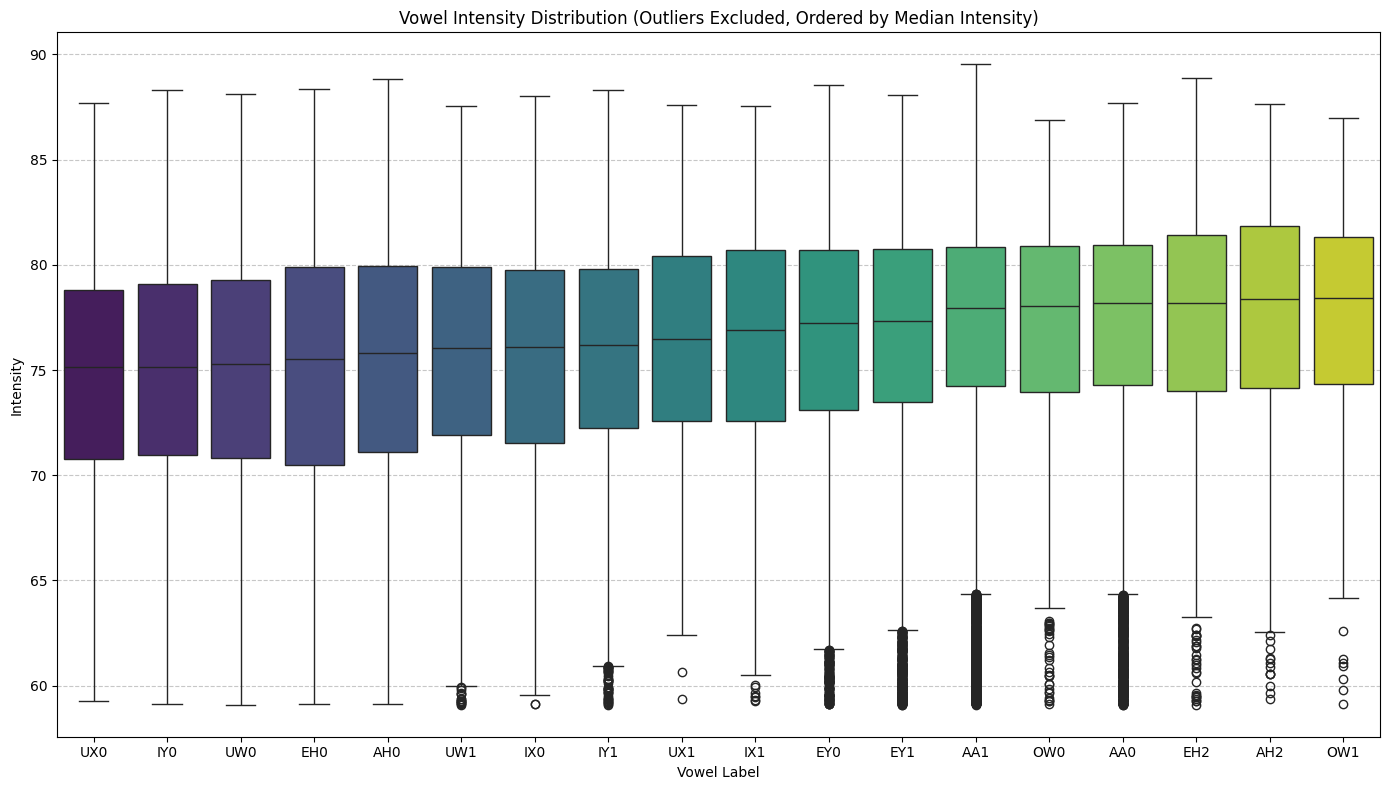

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # For f_oneway (ANOVA)
from statsmodels.stats.multicomp import pairwise_tukeyhsd # For Tukey HSD
import pandas as pd # Ensure pandas is imported if not already

# --- START: Dummy vowels_df creation for demonstration ---
# This block is for demonstration purposes. In your actual Jupyter Notebook,
# 'vowels_df' should already be populated from your data processing.
try:
    # Attempt to access vowels_df to see if it exists
    _ = vowels_df.head()
except NameError:
    print("Dummy 'vowels_df' created for demonstration. In actual use, ensure your 'vowels_df' is loaded.")
    data = {
        'label': np.random.choice(['a', 'e', 'i', 'o', 'u', 'ɪ', 'ɛ'], size=1000),
        'intensity': np.random.normal(loc=0.15, scale=0.05, size=1000) # Base durations
    }
    # Add some outliers and variations for testing
    data['intensity'][::10] = np.random.uniform(0.5, 1.0, size=100) # Longer outliers
    data['intensity'][data['label'] == 'a'] += 0.03 # Make 'a' slightly longer on average
    data['intensity'][data['label'] == 'i'] -= 0.02 # Make 'i' slightly shorter on average
    vowels_df = pd.DataFrame(data)
# --- END: Dummy vowels_df creation ---


if not vowels_df.empty:
    # 1. Outlier Filtering using IQR (from previous response)
    Q1 = vowels_df['intensity'].quantile(0.25)
    Q3 = vowels_df['intensity'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out data points outside the outlier bounds
    vowels_df_filtered = vowels_df[(vowels_df['intensity'] >= lower_bound) & (vowels_df['intensity'] <= upper_bound)]

    # 2. Arrange vowels from shortest to longest median duration
    # Calculate median duration for each vowel label in the filtered data
    median_durations = vowels_df_filtered.groupby('label')['intensity'].median().sort_values()
    ordered_vowels = median_durations.index.tolist()

    plt.figure(figsize=(14, 8)) # Increased figure size for better readability
    ax = sns.boxplot(data=vowels_df_filtered, x='label', y='intensity', palette='viridis', order=ordered_vowels)
    plt.title('Vowel Intensity Distribution (Outliers Excluded, Ordered by Median Intensity)')
    plt.xlabel('Vowel Label')
    plt.ylabel('Intensity')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # 3. Perform statistical tests for significance bars
    # Ensure there are at least two unique vowel labels after filtering to perform comparisons
    if len(ordered_vowels) > 1:
        # Prepare groups for ANOVA: a list of duration arrays for each vowel
        groups_for_anova = [vowels_df_filtered['intensity'][vowels_df_filtered['label'] == v] for v in ordered_vowels]
        # Filter out any empty groups that might result from filtering
        groups_for_anova = [g for g in groups_for_anova if not g.empty]

        if len(groups_for_anova) > 1:
            # Perform One-way ANOVA to test for overall significant differences
            f_stat, p_anova = stats.f_oneway(*groups_for_anova)
            print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_anova:.3f}")

            # If ANOVA is significant, proceed with post-hoc Tukey HSD test for pairwise comparisons
            if p_anova < 0.05: # Common significance level
                print("\nANOVA results indicate significant differences between vowel groups (p < 0.05).")
                print("Performing Tukey HSD post-hoc test for pairwise comparisons:")

                # Perform Tukey HSD
                tukey_result = pairwise_tukeyhsd(endog=vowels_df_filtered['intensity'],
                                                  groups=vowels_df_filtered['label'],
                                                  alpha=0.05) # Significance level
                print(tukey_result) # Prints a table of pairwise comparisons

                # 4. Add significance bars using the 'statannotations' library
                try:
                    from statannotations.Annotator import Annotator
                    print("\n'statannotations' library found. Drawing significance bars for significant pairwise differences...")

                    comparison_pairs = []
                    p_values_for_annotator = []

                    # Iterate through Tukey HSD results to identify significant pairs
                    rows = tukey_result.summary().data[1:] # Skip header row of the summary table
                    for row_data in rows:
                        group1, group2, _, _, p_value, reject_null = row_data
                        # If the null hypothesis is rejected, this pair is significantly different
                        if reject_null: # 'reject_null' is True if p_value < alpha (0.05 in this case)
                            # Ensure the pair is ordered correctly for statannotations based on 'ordered_vowels'
                            idx1 = ordered_vowels.index(group1)
                            idx2 = ordered_vowels.index(group2)

                            if idx1 < idx2:
                                pair = (group1, group2)
                            else:
                                pair = (group2, group1)

                            comparison_pairs.append(pair)
                            p_values_for_annotator.append(p_value)

                    if comparison_pairs:
                        # Initialize Annotator with the axis, comparison pairs, data, and column names
                        annotator = Annotator(ax, comparison_pairs, data=vowels_df_filtered,
                                              x='label', y='intensity', order=ordered_vowels)
                        # Configure to use star notation (*, **, ***) for significance and place bars outside the plot area
                        annotator.configure(test=None, text_format='star', loc='outside')
                        # Pass the pre-calculated p-values to the annotator for drawing
                        annotator.set_pvalues_and_annotate(p_values=p_values_for_annotator)
                    else:
                        print("No significant pairwise differences (p < 0.05) found to annotate on the plot.")

                except ImportError:
                    print("\n'statannotations' library not found. To draw significance bars on the plot, please install it:")
                    print("pip install statannotations")
                    print("Proceeding without drawing significance bars on the plot, but Tukey HSD results are printed above.")
            else:
                print("\nANOVA results indicate no significant overall differences between vowel groups (p >= 0.05).")
                print("Skipping post-hoc Tukey HSD test and significance bar drawing.")
        else:
            print("Not enough non-empty vowel groups in the filtered data to perform ANOVA and statistical comparisons.")
    else:
        print("Not enough unique vowel labels in the filtered data to perform statistical comparisons.")

    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()
else:
    print("No vowel data available for duration plot.")

/tmp/ipython-input-1678497727.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=vowels_df_filtered, x='label', y='f0', palette='viridis', order=ordered_vowels)


ANOVA F-statistic: 95.39, p-value: 0.000

ANOVA results indicate significant differences between vowel groups (p < 0.05).
Performing Tukey HSD post-hoc test for pairwise comparisons:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
   AA0    AA1  -0.3161    1.0  -1.7887   1.1565  False
   AA0    AH0  -1.6333 0.1269  -3.4272   0.1606  False
   AA0    AH2  16.1117    0.0  12.2968  19.9265   True
   AA0    EH0   -1.546 0.2114   -3.358    0.266  False
   AA0    EH2  17.7639    0.0   13.481  22.0468   True
   AA0    EY0   2.4279  0.006   0.3466   4.5091   True
   AA0    EY1    5.761    0.0    4.184    7.338   True
   AA0    IX0  10.6835    0.0   6.5361   14.831   True
   AA0    IX1  15.9735    0.0  11.1679  20.7791   True
   AA0    IY0   5.2662    0.0   3.0556   7.4767   True
   AA0    IY1  12.9711    0.0  10.6123    15.33   True
   AA0    OW0   1.5657 0.9921   -2.127   5.2584

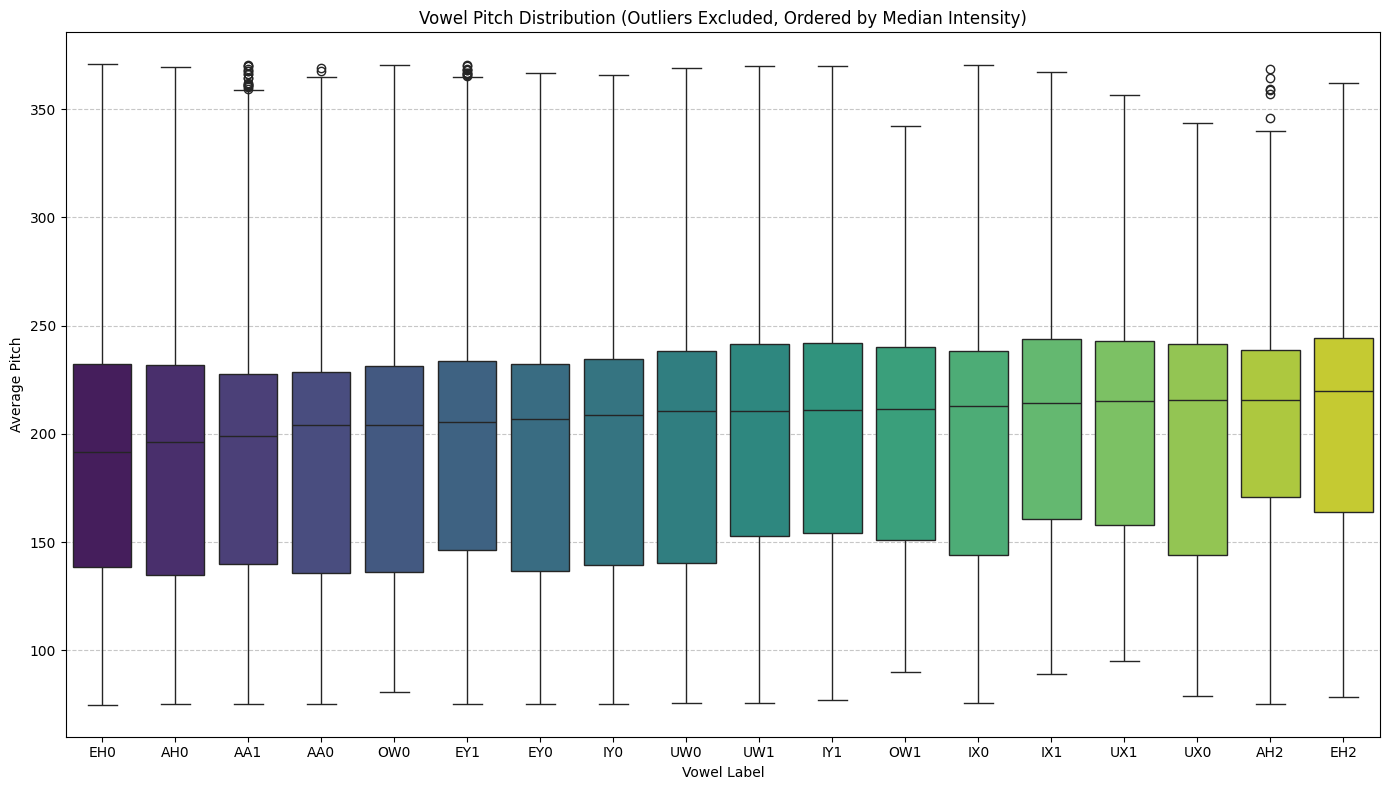

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # For f_oneway (ANOVA)
from statsmodels.stats.multicomp import pairwise_tukeyhsd # For Tukey HSD
import pandas as pd # Ensure pandas is imported if not already

# --- START: Dummy vowels_df creation for demonstration ---
# This block is for demonstration purposes. In your actual Jupyter Notebook,
# 'vowels_df' should already be populated from your data processing.
try:
    # Attempt to access vowels_df to see if it exists
    _ = vowels_df.head()
except NameError:
    print("Dummy 'vowels_df' created for demonstration. In actual use, ensure your 'vowels_df' is loaded.")
    data = {
        'label': np.random.choice(['a', 'e', 'i', 'o', 'u', 'ɪ', 'ɛ'], size=1000),
        'f0': np.random.normal(loc=0.15, scale=0.05, size=1000) # Base durations
    }
    # Add some outliers and variations for testing
    data['f0'][::10] = np.random.uniform(0.5, 1.0, size=100) # Longer outliers
    data['f0'][data['label'] == 'a'] += 0.03 # Make 'a' slightly longer on average
    data['f0'][data['label'] == 'i'] -= 0.02 # Make 'i' slightly shorter on average
    vowels_df = pd.DataFrame(data)
# --- END: Dummy vowels_df creation ---


if not vowels_df.empty:
    # 1. Outlier Filtering using IQR (from previous response)
    Q1 = vowels_df['f0'].quantile(0.25)
    Q3 = vowels_df['f0'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out data points outside the outlier bounds
    vowels_df_filtered = vowels_df[(vowels_df['f0'] >= lower_bound) & (vowels_df['f0'] <= upper_bound)]

    # 2. Arrange vowels from shortest to longest median duration
    # Calculate median duration for each vowel label in the filtered data
    median_durations = vowels_df_filtered.groupby('label')['f0'].median().sort_values()
    ordered_vowels = median_durations.index.tolist()

    plt.figure(figsize=(14, 8)) # Increased figure size for better readability
    ax = sns.boxplot(data=vowels_df_filtered, x='label', y='f0', palette='viridis', order=ordered_vowels)
    plt.title('Vowel Pitch Distribution (Outliers Excluded, Ordered by Median Intensity)')
    plt.xlabel('Vowel Label')
    plt.ylabel('Average Pitch')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # 3. Perform statistical tests for significance bars
    # Ensure there are at least two unique vowel labels after filtering to perform comparisons
    if len(ordered_vowels) > 1:
        # Prepare groups for ANOVA: a list of duration arrays for each vowel
        groups_for_anova = [vowels_df_filtered['f0'][vowels_df_filtered['label'] == v] for v in ordered_vowels]
        # Filter out any empty groups that might result from filtering
        groups_for_anova = [g for g in groups_for_anova if not g.empty]

        if len(groups_for_anova) > 1:
            # Perform One-way ANOVA to test for overall significant differences
            f_stat, p_anova = stats.f_oneway(*groups_for_anova)
            print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_anova:.3f}")

            # If ANOVA is significant, proceed with post-hoc Tukey HSD test for pairwise comparisons
            if p_anova < 0.05: # Common significance level
                print("\nANOVA results indicate significant differences between vowel groups (p < 0.05).")
                print("Performing Tukey HSD post-hoc test for pairwise comparisons:")

                # Perform Tukey HSD
                tukey_result = pairwise_tukeyhsd(endog=vowels_df_filtered['f0'],
                                                  groups=vowels_df_filtered['label'],
                                                  alpha=0.05) # Significance level
                print(tukey_result) # Prints a table of pairwise comparisons

                # 4. Add significance bars using the 'statannotations' library
                try:
                    from statannotations.Annotator import Annotator
                    print("\n'statannotations' library found. Drawing significance bars for significant pairwise differences...")

                    comparison_pairs = []
                    p_values_for_annotator = []

                    # Iterate through Tukey HSD results to identify significant pairs
                    rows = tukey_result.summary().data[1:] # Skip header row of the summary table
                    for row_data in rows:
                        group1, group2, _, _, p_value, reject_null = row_data
                        # If the null hypothesis is rejected, this pair is significantly different
                        if reject_null: # 'reject_null' is True if p_value < alpha (0.05 in this case)
                            # Ensure the pair is ordered correctly for statannotations based on 'ordered_vowels'
                            idx1 = ordered_vowels.index(group1)
                            idx2 = ordered_vowels.index(group2)

                            if idx1 < idx2:
                                pair = (group1, group2)
                            else:
                                pair = (group2, group1)

                            comparison_pairs.append(pair)
                            p_values_for_annotator.append(p_value)

                    if comparison_pairs:
                        # Initialize Annotator with the axis, comparison pairs, data, and column names
                        annotator = Annotator(ax, comparison_pairs, data=vowels_df_filtered,
                                              x='label', y='f0', order=ordered_vowels)
                        # Configure to use star notation (*, **, ***) for significance and place bars outside the plot area
                        annotator.configure(test=None, text_format='star', loc='outside')
                        # Pass the pre-calculated p-values to the annotator for drawing
                        annotator.set_pvalues_and_annotate(p_values=p_values_for_annotator)
                    else:
                        print("No significant pairwise differences (p < 0.05) found to annotate on the plot.")

                except ImportError:
                    print("\n'statannotations' library not found. To draw significance bars on the plot, please install it:")
                    print("pip install statannotations")
                    print("Proceeding without drawing significance bars on the plot, but Tukey HSD results are printed above.")
            else:
                print("\nANOVA results indicate no significant overall differences between vowel groups (p >= 0.05).")
                print("Skipping post-hoc Tukey HSD test and significance bar drawing.")
        else:
            print("Not enough non-empty vowel groups in the filtered data to perform ANOVA and statistical comparisons.")
    else:
        print("Not enough unique vowel labels in the filtered data to perform statistical comparisons.")

    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()
else:
    print("No vowel data available for duration plot.")

LingMethodsHub

In [ ]:
#Import libraries

import matplotlib.pyplot as plt
import pandas as pd
from pandas import DataFrame
import seaborn as sns
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter

In [ ]:
def vowelplot (vowelcsv, color=None, F1="F1", F2="F2", vowel="Vowel", title="Vowel Plot", unit="Hz", logscale=True):

    #Set some parameters for the chart itself
    sns.set(style='ticks', context='notebook')
    plt.figure(figsize=(6,6))

    # If there's an argument for color, determine whether it's likely to be categorical
    ## If it's a string (text), use a categorical color palette
    ## If it's a number, use a sequential color palette
    if color != None:
        if type(vowelcsv[color].iloc[0])==str:
            pal = "husl"
        else:
            pal = "viridis"

        pl = sns.scatterplot(x = F2,
                             y = F1,
                             hue = color,
                             data = vowelcsv,
                             palette = pal)

    # If no color argument is given, don't specify hue, and no palette needed
    else:
        pl = sns.scatterplot(x = F2,
                             y = F1,
                             data = vowelcsv)


    #Invert axes to correlate with articulatory space!
    pl.invert_yaxis()
    pl.invert_xaxis()

    #Add unit to the axis labels
    F1name = str("F1 ("+unit+")")
    F2name = str("F2 ("+unit+")")
    laby = plt.ylabel(F1name)
    labx = plt.xlabel(F2name)

    if logscale == True:
        pl.loglog()
        pl.yaxis.set_major_formatter(ticker.ScalarFormatter())
        pl.yaxis.set_minor_formatter(ticker.ScalarFormatter())
        pl.xaxis.set_major_formatter(ticker.ScalarFormatter())
        pl.xaxis.set_minor_formatter(ticker.ScalarFormatter())

    # Add vowel labels

    if vowel != None:
        for line,row in vowelcsv.iterrows():
            pl.text(vowelcsv[F2][line]+0.1,
                    vowelcsv[F1][line],
                    vowelcsv[vowel][line],
                    horizontalalignment = 'left',
                    size = 14, # Edit for larger plots!
                    color = 'black',
                   # weight = 'semibold' # Uncomment for larger plots!
                   )

    pl.set_title(title)
    plt.show()

    return pl



def barkify (data, formants):
    # For each formant listed, make a copy of the column prefixed with z
    for formant in formants:
        for ch in formant:
            if ch.isnumeric():
                num = ch
        formantchar = (formant.split(num)[0])
        name = str(formant).replace(formantchar,'z')
        # Convert each value from Hz to Bark
        data[name] = 26.81/ (1+ 1960/data[formant]) - 0.53
    # Return the dataframe with the changes
    return data

def Lobify (data, group, formants):
    zscore = lambda x: (x - x.mean()) / x.std()
    for formant in formants:
        name = str("zsc_" + formant)
        col = data.groupby([group])[formant].transform(zscore)
        data.insert(len(data.columns), name, col)
    return data

In [9]:
voweldata = pd.read_csv('all_chuvash_vowel_points.csv')

In [10]:
voweldata.head(5)

,F1,F2,F3,B1,B2,B3,max_formant,smooth_error,time,rel_time,...,stress,dur,pre_word,fol_word,pre_seg,fol_seg,abs_pre_seg,abs_fol_seg,context,corpus
0,660.298652,1532.768769,2391.914843,4.406848,4.429939,4.391230,4435.897436,0.090970,0.116750,0.129,...,NaN,0.36,#,шупашкар,#,#,N,SH,coextensive,mfa
1,276.734812,2112.413084,2793.023192,3.367200,3.541821,3.977945,4615.384615,0.002088,0.921375,0.035,...,0.0,0.08,шупашкар,ӑна,tʃ,N,tʃ,N,internal,mfa
2,387.886251,1908.840620,2986.247885,3.867536,3.771904,3.794694,5333.333333,0.015417,1.171375,0.035,...,0.0,0.08,шупашкар,ӑна,N,K,N,K,internal,mfa
3,454.315233,1501.979460,2204.399306,4.157943,4.253752,4.795730,4794.871795,0.000454,1.027375,0.027,...,0.0,0.06,шупашкар,ӑна,N,V,N,V,internal,mfa
4,348.960853,1882.597958,2426.138280,2.890679,2.900916,3.315269,4615.384615,0.000008,1.277375,0.027,...,0.0,0.06,шупашкар,ӑна,K,S,K,S,internal,mfa


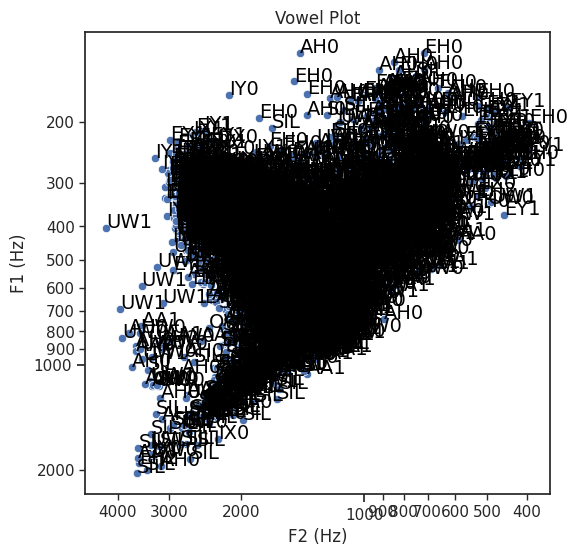

<Axes: title={'center': 'Vowel Plot'}, xlabel='F2 (Hz)', ylabel='F1 (Hz)'>

In [ ]:
vowelplot(voweldata,
          F1 = "F1",
          F2 = "F2",
          vowel = "label")